# 01 — Data Inspection
Load raw events, validate schema, show event type distribution, shot counts per match.

In [2]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import RAW_DIR, MATCHES_FILE
from load_data import load_match_ids, load_competition_events

In [3]:
# Load match IDs
match_ids = load_match_ids(MATCHES_FILE)
print(f'Found {len(match_ids)} matches in 106.json')
print('Sample IDs:', match_ids[:5])

Found 64 matches in 106.json
Sample IDs: [3857254, 3857255, 3857256, 3857257, 3857258]


In [4]:
# Load all competition events
events_df = load_competition_events(RAW_DIR, match_ids)
print(f'\nDataFrame shape: {events_df.shape}')
print('\nColumn dtypes:')
print(events_df.dtypes)

Loaded 64 matches, 234652 events
  Shots: 1494  |  Goals: 195
  Unique event types (33): ['50/50', 'Bad Behaviour', 'Ball Receipt*', 'Ball Recovery', 'Block', 'Carry', 'Clearance', 'Dispossessed', 'Dribble', 'Dribbled Past', 'Duel', 'Error', 'Foul Committed', 'Foul Won', 'Goal Keeper', 'Half End', 'Half Start', 'Injury Stoppage', 'Interception', 'Miscontrol', 'Offside', 'Own Goal Against', 'Own Goal For', 'Pass', 'Player Off', 'Player On', 'Pressure', 'Referee Ball-Drop', 'Shield', 'Shot', 'Starting XI', 'Substitution', 'Tactical Shift']

DataFrame shape: (234652, 21)

Column dtypes:
match_id                  int64
event_id                 object
index                     int64
period                    int64
minute                    int64
second                    int64
event_time_min          float64
type_name                object
team_name                object
team_id                   int64
possession                int64
possession_team_name     object
play_pattern_name        

In [5]:
# Schema validation
required_cols = [
    'match_id', 'event_id', 'index', 'period', 'minute', 'second',
    'event_time_min', 'type_name', 'team_name', 'team_id',
    'possession', 'possession_team_name', 'play_pattern_name',
    'player_name', 'under_pressure', 'location_x', 'location_y',
    'shot_xg', 'shot_outcome_name', 'is_goal', 'is_shot'
]
missing = [c for c in required_cols if c not in events_df.columns]
print('Missing required columns:', missing if missing else 'None — schema OK')

Missing required columns: None — schema OK


In [6]:
# Event type distribution
type_counts = events_df['type_name'].value_counts()
print('Event type counts (top 20):')
print(type_counts.head(20))

Event type counts (top 20):
type_name
Pass               68515
Ball Receipt*      63715
Carry              53764
Pressure           16553
Ball Recovery       5821
Duel                4389
Clearance           2684
Block               2386
Dribble             1793
Goal Keeper         1790
Foul Committed      1775
Miscontrol          1755
Foul Won            1693
Shot                1494
Dispossessed        1431
Interception        1371
Dribbled Past       1036
Substitution         587
Injury Stoppage      403
Half End             286
Name: count, dtype: int64


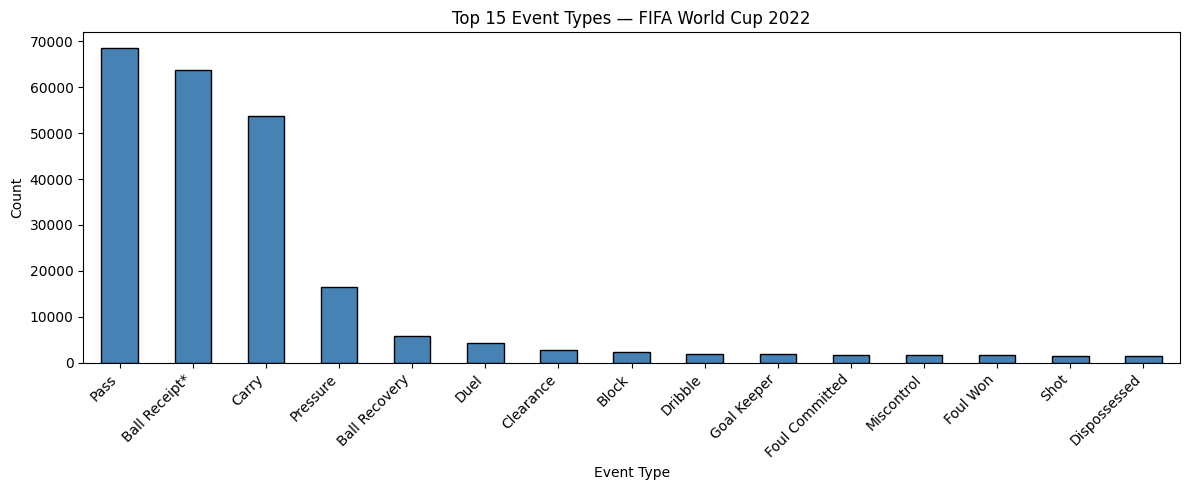

In [7]:
# Plot event type distribution (top 15)
fig, ax = plt.subplots(figsize=(12, 5))
type_counts.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 15 Event Types — FIFA World Cup 2022')
ax.set_xlabel('Event Type')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Shots per match — mean: 23.3, min: 9, max: 38


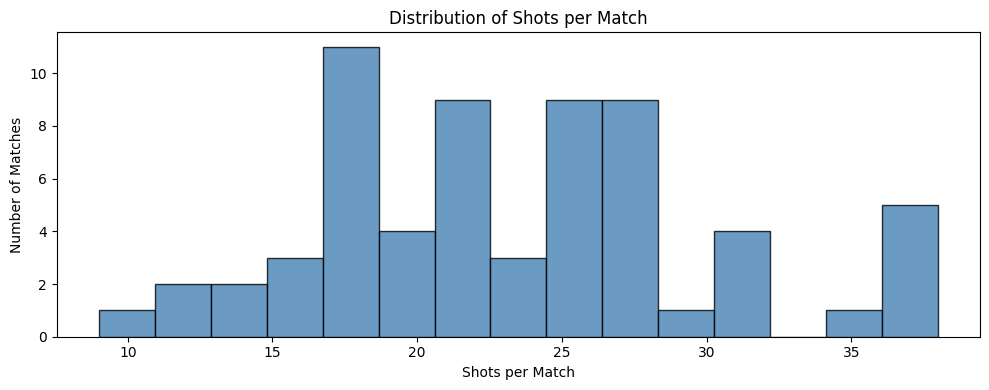

In [8]:
# Shot counts per match
shots_per_match = events_df[events_df['is_shot'] == 1].groupby('match_id').size().reset_index(name='n_shots')
print(f'Shots per match — mean: {shots_per_match["n_shots"].mean():.1f}, '
      f'min: {shots_per_match["n_shots"].min()}, max: {shots_per_match["n_shots"].max()}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(shots_per_match['n_shots'], bins=15, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Shots per Match')
ax.set_ylabel('Number of Matches')
ax.set_title('Distribution of Shots per Match')
plt.tight_layout()
plt.show()

In [9]:
# Goal and xG summary
shots_only = events_df[events_df['is_shot'] == 1]
print(f'Total shots: {len(shots_only)}')
print(f'Total goals: {shots_only["is_goal"].sum()}')
print(f'xG range: {shots_only["shot_xg"].min():.4f} — {shots_only["shot_xg"].max():.4f}')
print(f'Mean xG per shot: {shots_only["shot_xg"].mean():.4f}')

Total shots: 1494
Total goals: 195
xG range: 0.0002 — 0.8975
Mean xG per shot: 0.1259
